In [ ]:
import kagglehub
import os

# Download latest version
base_path = kagglehub.dataset_download("ksir0423/stationery-dataset-1")

# Adjust path to point to the actual data directory
path = os.path.join(base_path, 'Data')

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stationery-dataset-1' dataset.
Path to dataset files: /kaggle/input/stationery-dataset-1/Data


In [ ]:
import tensorflow as tf

# Check for GPU activity
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Number of GPUs Available: {len(gpus)}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU is available and memory growth is enabled.")
else:
    print("No GPU devices found. Training will run on CPU.")

Number of GPUs Available: 1
GPU is available and memory growth is enabled.


### Dataset Preparation

I will now load the image dataset from the path downloaded by `kagglehub`. It is assumed that the dataset at `/kaggle/input/stationery-dataset-1` contains subdirectories where each subdirectory represents a class of images (e.g., `path/class_a/img1.jpg`, `path/class_b/img2.jpg`).

I will use `tf.keras.utils.image_dataset_from_directory` to load the data, resize images, and create training and validation splits.

In [ ]:
IMAGE_SIZE = (224, 224) # MobileNetV2 input size
BATCH_SIZE = 32

# Load the dataset using the path from the previous cell
# Assuming the dataset structure is 'path/class_name/image.jpg'
try:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        path,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        path,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)
    print(f"Found {num_classes} classes: {class_names}")

    # Configure the dataset for performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure the dataset at '/kaggle/input/stationery-dataset-1' has the expected directory structure (e.g., 'dataset_root/class1/image.jpg').")

Found 1774 files belonging to 2 classes.
Using 1420 files for training.
Found 1774 files belonging to 2 classes.
Using 354 files for validation.
Found 2 classes: ['Test', 'Train']


### Build MobileNet Model

I will now build the MobileNetV2 model. I'll use a pre-trained MobileNetV2 as a feature extractor (without its top classification layer) and add a custom classification head suited for our specific dataset.

In [ ]:
if 'train_ds' in locals():
    # Create the base model from the pre-trained MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMAGE_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )

    # Freeze the base model to prevent weights from being updated during training
    base_model.trainable = False

    # Create a new model on top
    inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
    # Preprocess the input images for MobileNetV2
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x) # Add a dropout layer for regularization
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(), # Use if labels are integers
        metrics=['accuracy']
    )

    model.summary()
else:
    print("Skipping model building: Dataset not loaded successfully.")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Train the Model

Now, let's train the MobileNetV2 model using the prepared dataset.

In [ ]:
if 'model' in locals():
    EPOCHS = 10
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds
    )
else:
    print("Skipping model training: Model not built successfully.")

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 320ms/step - accuracy: 0.6261 - loss: 0.6975 - val_accuracy: 0.7119 - val_loss: 0.6806
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6915 - loss: 0.6421 - val_accuracy: 0.7175 - val_loss: 0.6638
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7092 - loss: 0.6351 - val_accuracy: 0.7260 - val_loss: 0.6504
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6986 - loss: 0.6269 - val_accuracy: 0.7288 - val_loss: 0.6416
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7246 - loss: 0.6024 - val_accuracy: 0.7345 - val_loss: 0.6291
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7000 - loss: 0.6142 - val_accuracy: 0.7316 - val_loss: 0.6374
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7239 - loss: 0.6024 - val_accuracy: 0.7373 - val_loss: 0.6192
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7134 - loss: 0.6049 - val_accuracy: 0.7429 -

### Inspecting Dataset Directory Structure

Before adjusting the model, let's verify the actual directory structure within the downloaded dataset. This will help us understand why only one class ('Data') was detected. We will list the contents of the `path` variable.

In [ ]:
import os

print(f"Contents of {path}:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
    else:
        print(f"  [FILE] {item}")

Contents of /kaggle/input/stationery-dataset-1/Data:
  [DIR] Test
  [DIR] Train


### Summarize Training Results

After training, let's evaluate the model's performance on the validation set.

In [ ]:
if 'model' in locals() and 'val_ds' in locals():
    print("\nEvaluating the model...")
    loss, accuracy = model.evaluate(val_ds)
    print(f"Validation Loss: {loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
else:
    print("Skipping model evaluation: Model or validation dataset not available.")


Evaluating the model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7458 - loss: 0.6114
Validation Loss: 0.6114
Validation Accuracy: 0.7458


### Display Training History Plots

Finally, let's visualize the training and validation accuracy and loss over the epochs to understand the model's learning progress.

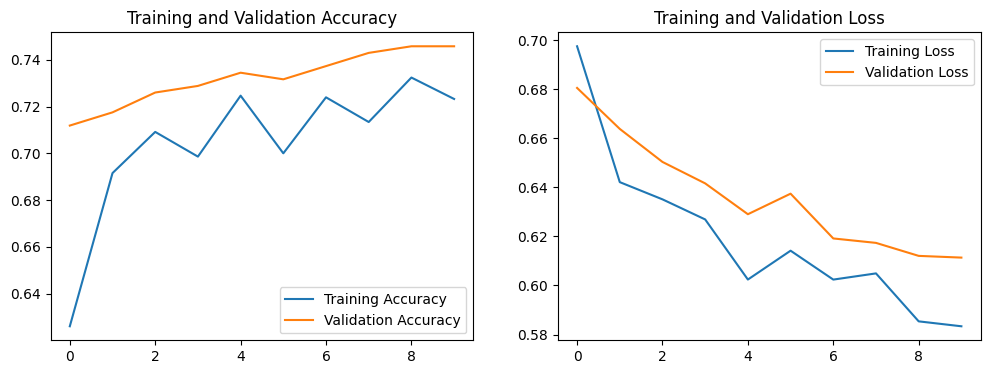

In [ ]:
import matplotlib.pyplot as plt

if 'history' in locals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(EPOCHS)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()
else:
    print("Skipping plotting: Training history not available (model might not have been trained).")